# 2D PISCO sensitivity map estimation demo
This notebook goes step by step through the PISCO technique to estimate coil sensitivity maps from 2D multichannel MRI k-space data. One could achieve the same results by directly calling the `pisco_smaps` function in `pisco.jl` as we do in the beginning of the notebook.

In [ ]:
# load packages
using MIRTjim
using Plots
using FFTW
using Random
using LinearAlgebra
using MAT
using LinearMapsAA
using pisco

## Read in the k-space data
First, we read in 2D k-space data with dimensions $N \times N \times Q$, where $Q$ is the number of receiver coil channels. The example data is fully sampled, but can be undersampled as long as there is a fully sampled region at the center of k-space which is used to estimate the sensitivity maps.

In [125]:
# read in data from mat file
kdata = 1e8 * matread("./data/2D_T1_data.mat")["kData"];

# get sizes
nd = ndims(kdata) - 1; # number of image dimensions
N = size(kdata)[1:nd]; # image size
Q = size(kdata, nd + 1); # number of channels

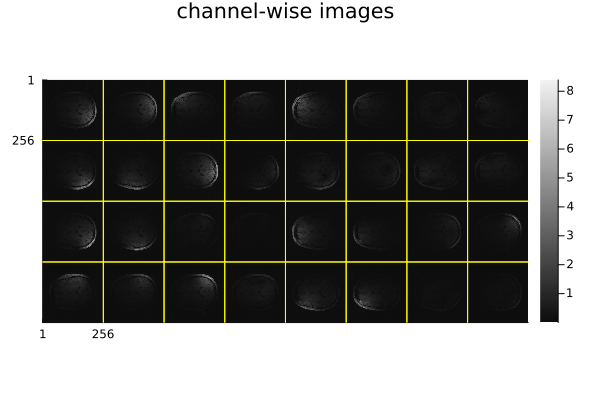

In [126]:
# show the multi-channel image data
idata = iftnd(kdata; dims=1:nd);
jim(idata, title="channel-wise images")

## Set PISCO parameters and techniques

PISCO proposes several techniques to improve speed and performance over other nullspace-based estimation methods. These techniques include:

- Using ellipsoidal neighborhood kernels in place of rectangular kernels
- FFT-based construction of the convolution gram matrix, $C^HC$
- Sketched (randomized) SVD (and projection matrix-based construction of the filter gram matrix, $G$)
- Subspace iteration-based estimation of the nullspace vectors of $G$

Several tunable parameters are referenced in the PISCO tecnique. These include:

- $\tau \in \mathbb{Z}$: kernel neighborhood size (radius)
- $N_\text{cal} \in \mathbb{Z}$: size of the fully sampled calibration region at center of k-space, in each dimension
- $\sigma_\text{thresh} \in (0,1)$: normalized singular value threshold for determining the rank of $C^HC$
- $d_\text{sk} \in \mathbb{Z}$: sketch dimension for sketched SVD of $C^HC$. This should over-estimate the rank of $C^HC$!
- $N_\text{gzp} \in \mathbb{Z}$: number of points to zero-pad k-space of G (initial fft interpolation)
- $\alpha \in \mathbb{R}$: Gaussian apodizing window parameter for phase normalization

In [127]:
# set PISCO techniques
kernel_shape = 1; # (0 for rect, 1 for circle)
fft_C_mtx = 1; # option to approximate ChC with FFTs
sketched_SVD = 1; # option to used sketched (randomized) SVD
subspace_itr_G = 0; # option to use subspace iteration to compute nullspace vectors of G

# set PISCO parameters
τ = Int(3); # neighborhood size (radius)
N_cal = 32; # size of calibration region
σ_thresh = 0.002; # threshold for singular values
d_sk = 50; # sketch dimension for SVD of ChC (overestimation of the rank)
N_gzp = 24; # number of vo/pixels to interpolate (zero-pad) in each dimension of G matrix
α = 100; # Gaussian window parameter for phase normalization
L = 1; # number of sensitivity map sets to estimate

## Estimate sensitivity maps using the `pisco_smaps` function

We will demonstrate the PISCO method step by step, but the same results can also be achieved by calling the `pisco_smaps` function as in the following cell:

In [ ]:
# estimate the sensitivity maps by calling the pisco_smaps function
smaps,λ,_ = pisco_smaps(kdata;
    kernel_shape=kernel_shape,
    fft_C_mtx=fft_C_mtx,
    sketched_SVD=sketched_SVD,
    subspace_itr_G=subspace_itr_G,
    σ_thresh=σ_thresh,
    d_sk=d_sk,
    N_gzp=N_gzp,
    α=α,
    L=L,
    verbose=1);

UndefVarError: UndefVarError: `kernel_shape` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

Now we will demonstrate the PISCO method step-by-step.

## Form the convolution (Gram) matrix, $C^HC$, from calibration data

By the assumption of shift-invariant linear predictability (SILP), given the multi-coil k-space data $s_q[n]$, there should exist $R$ distinct $Q$-channel finite impulse response (FIR) filters $h_r[n,q]$ such that:

$$
\sum_{q=1}^Q \sum_{m \in \Lambda} h_r[m,q]s_q[n-m] \approx 0, \quad \forall n \in \mathbb{Z}^D, \quad \forall r = 1,2,...R
$$

Where $\Lambda \subset \mathbb{Z}^D$ is a finite index set describing the support (neighborhood) of each filter.

This convolution can also be represented in matrix form as:

$$ 
Ch_r \approx 0, \quad \forall r = 1,2,...R
$$

Where $C \in \mathbb{C}^{P \times |\Lambda|Q}$ is a block matrix containing convolution-structured matrices (i.e. Toeplitz or Hankel) for each channel. $P$ represents the number of $n$ values used in the convolution, $|\Lambda|$ is size of the neighborhood set, and $Q$ the number of channels.

This implies that $h_r \in \mathcal{N}(C)$, where $\mathcal{N}(C)$ is the nullspace of $C$. Therefore, we can find the $R$ distinct $Q$-channel finite impulse response (FIR) filters $h_r[n,q]$ by forming the convolution-structured matrix $C$ from the calibration data and a kernel neighborhood $\Lambda$ and estimating its nullspace.

Since the matrix $C^HC$ shares a nullspace with $C$ and is often smaller than $C$ (i.e. $P < |\Lambda|Q$), we choose to work with $C^HC$ instead to estimate the filters.

See Section A in [1] for more info.

In [129]:
# extract calibration data from kcal
cal_sidx = center_idcs(N, N_cal * ones(nd)); # subscript indices for calibration region (vector of vectors for each dim)
kcal = kdata[cal_sidx..., :];

# create kernel neighborhood
Λ_cidx = grid([-τ:τ for d in 1:nd]...); # coordinate indicies for kernel neighborhood
if kernel_shape == 1
    cmask = vec(sum(Λ_cidx.^2, dims=2)) .<= τ^2;
    Λ_cidx = Λ_cidx[cmask, :] # mask out edges if using ellipsoidal kernel
end
Λ_len = size(Λ_cidx,1); # final kernel (patch) size


In [ ]:
# form the convolution gram matrix ChC
if fft_C_mtx == 0 # naive approach
    C = C_matrix(kcal, Λ_cidx, N_cal); # calculate convolution matrix C explicitly
    ChC = C' * C; # calculate ChC via matrix product
else # direct FFT-based approach
    ChC = ChC_matrix_fft(kcal, Λ_cidx, N_cal);
end

## Determine the nullspace of $C^HC$
We can estimate the filters $h_r$ as the nullspace vectors of $C^HC$. This can be done by computing the SVD of $C^HC$ and taking the last $|\Lambda|Q - \text{rank}(C^HC)$ rowspace vectors which form a basis for the nullspace of $C^HC$.

Since we will need the projection matrix of this nullspace basis, we can also estimate it as:

In [ ]:
if sketched_SVD == 0 # full SVD of ChC
    (~,σ,V) = svd(ChC);
else # sketched SVD of ChC
    S_sk = 1/sqrt(d_sk) * (randn(d_sk, Λ_len*Q) + 1im * randn(d_sk, Λ_len*Q)); 
    (~,σ,V) = svd(S_sk * ChC);
end
r = count(σ/σ[1] .> σ_thresh);
Vr = V[:, 1:r]; # get the column space basis of C

## Calculate the G matrix

In [ ]:
# get null space projection matrix
W = I - Vr * Vr';

# calculate the G matrix
G = G_matrix(W, Λ_cidx, N_cal, N_gzp); # form the G matrix
G = reshape(G, (N_cal + N_gzp)^nd, Q, Q); # reshape G into (vo/pixels) x Q x Q array

## Estimate the sensitivity maps from the nullspace of $G$

In [ ]:
# estimate sensitivity maps from G
smaps_lores = zeros(ComplexF64, Q, L, (N_cal + N_gzp)^nd);
λ_lores = zeros(ComplexF64, Q, (N_cal + N_gzp)^nd);
for x in 1:(N_cal + N_gzp)^nd # loop through vo/pixels
    # estimate sensitivities at vo/pixel x as last L null space vectors of G(x)
    if subspace_itr_G == 1 # using subspace iteration
        (σ, V) = subspace_iteration(G[x, :, :], L; maxit=30, tol=1e-6);
    else # using svd
        (~, σ, V) = svd(G[x, :, :])
    end
    smaps_lores[:, :, x] = V[:, end-L+1:end]
    λ_lores[:, x] = σ
end
smaps_lores = permutedims(reshape(smaps_lores, Q, L, (N_cal + N_gzp) * ones(Int, nd)...), ((3:nd+2)..., 1, 2));
λ_lores = permutedims(reshape(λ_lores, Q, (N_cal + N_gzp) * ones(Int, nd)...), ((2:nd+1)..., 1));

## Normalize the phase

In [ ]:
# create nd apodizing window for phase normalization
apodizing_window = ones(ComplexF64, (N_cal + N_gzp)*ones(Int, nd)...);
for d in 1:nd
    shape = ntuple(i -> i == d ? (N_cal + N_gzp) : 1, nd);
    apodizing_window .*= reshape(gausswin(N_cal + N_gzp; α), shape);
end

# get low-resolution image data
ft_idata_lores = zero_pad(kcal; N=((N_cal + N_gzp)*ones(Int,nd)..., Q));
idata_lores = iftnd(ft_idata_lores .* apodizing_window; dims=1:nd);

# normalize the phase of the sensitivity maps based on the low-resolution image data
cim = sum(conj.(smaps_lores) .* idata_lores; dims=nd+1) ./ sum(abs2.(smaps_lores); dims=nd+1);
phase_norm = exp.(1im * angle.(cim));
smaps_lores_corr = smaps_lores .* phase_norm; # apply phase normalization

In [ ]:
# show the low-resolution sensitivity maps before and after phase normalization
p1 = jim(smaps_lores, title="low-res SENSE map\n(magnitude, uncorrected)")
p2 = jim(smaps_lores_corr, title="low-res SENSE map\n(magnitude, phase normalized)")
p3 = jim(angle.(smaps_lores), title="low-res SENSE map\n(phase, uncorrected)")
p4 = jim(angle.(smaps_lores_corr), title="low-res SENSE map\n(phase, phase normalized)")
plot(p1, p2, p3, p4, layout=(2, 2), size=(1200, 700))

## Interpolate the sensitivity maps

In [ ]:
# create nd hanning window for fft interpolation
w_sm = ones(ComplexF64, (N_cal + N_gzp) * ones(Int, nd)...);
for d in 1:nd
    shape = ntuple(i -> i == d ? (N_cal + N_gzp) : 1, nd);
    w_sm .*= reshape(hanningwin(N_cal + N_gzp), shape);
end

# interpolate sensitivity maps using fft
smaps = iftnd(ftnd(smaps_lores_corr; dims=1:nd) .* w_sm; dims=1:nd, N=(N..., Q, L));
λ = iftnd(ftnd(λ_lores; dims=1:nd) .* w_sm; dims=1:nd, N=(N..., Q));

In [ ]:
# show the sensitivity map interpolation results
p1 = jim(smaps_lores_corr, title="low-res SENSE map\n(magnitude)")
p2 = jim(smaps, title="high-res SENSE map\n(magnitude)")
p3 = jim(angle.(smaps_lores_corr), title="low-res SENSE map\n(phase)")
p4 = jim(angle.(smaps), title="high-res SENSE map\n(phase)")
plot(p1, p2, p3, p4, layout=(2, 2), size=(1200, 700))

In [ ]:
# show the eigenvalues of G
p1 = jim(λ_lores, title="low-res eigenvalues of G(x)")
p2 = jim(λ, title="high-res eigenvalues of G(x)")
plot(p1, p2, layout=(1,2), size=(1200,400))

## Calculate the representation error of the estimated sensitivity maps

In [ ]:
# create sensitivity encoding operator
S = LinearMapAA(
    x -> x.*smaps, # forward
    y -> sum(conj.(smaps) .* y, dims=nd+1), # adjoint
    (prod(N)*Q, prod(N)); # operator size
    T=ComplexF64, # data type
    idim=N, # input dimensions
    odim=(N..., Q) # output dimensions
    );

# solve for coil-combined image using conjugate gradient
idata_coil_combined = cg(S, zeros(ComplexF64, N...), idata; niter=30);

# get representation error (NPR)
@show npr = norm(idata[:] - (S * idata_coil_combined)[:]) / norm(idata[:]);

In [ ]:
# show the coil-combined image
jim(idata_coil_combined, title="coil-combined image")